In [ ]:
from string import ascii_lowercase
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

alph_eng = ascii_lowercase
alph_ru = "абвгдеёжзийклмнопрстуфхцчшщъыьэюя"
with open("cipher.txt", "r", encoding="cp866") as file:
  file = file.read()
text = file.replace("\n", "").lower()

clean_text = re.sub(r"[\s\-,.:/!()?_–«»…]", "", text)
clean_text = re.sub(r"[а-яА-ЯёЁ]", "", text)
print(len(clean_text))
#clean_text = re.sub(r'[^a-z]', '', clean_text.lower())
clean_text

17758


'wfcehcqvycefscprr,mn.xlcyxaj!:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnieftlct1.xysxqanvgjolhauxgtmehajaeidcazmgzfjehercprr!slwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajhahafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.xgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpderklvtpskvhhvlwlappoypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoypvwhptkezaszxsltwfmsfdrawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhpraraxspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxejexohwrcewx!msldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzitsazexpzp-wwxliywm,o

In [ ]:
ru_letters = {}
for i in alph_ru:
  ru_letters[i] = clean_text.count(i)

In [ ]:
ru_letters

{'а': 0,
 'б': 0,
 'в': 0,
 'г': 0,
 'д': 0,
 'е': 0,
 'ё': 0,
 'ж': 0,
 'з': 0,
 'и': 0,
 'й': 0,
 'к': 0,
 'л': 0,
 'м': 0,
 'н': 0,
 'о': 0,
 'п': 0,
 'р': 0,
 'с': 0,
 'т': 0,
 'у': 0,
 'ф': 0,
 'х': 0,
 'ц': 0,
 'ч': 0,
 'ш': 0,
 'щ': 0,
 'ъ': 0,
 'ы': 0,
 'ь': 0,
 'э': 0,
 'ю': 0,
 'я': 0}

In [ ]:
def find_freq(text):
  letters = {}
  alph_eng = ascii_lowercase
  for i in alph_eng:
    letters[i] = text.count(i) / len(text) * 100
  return letters

In [ ]:
from string import ascii_uppercase

def shift_abc(abc, k):
    return abc[k:] + abc[:k]

def caesar(text, k):
    shift_abc = lambda abc, k: abc[k:] + abc[:k]
    abc_lowercase = ascii_lowercase
    abc_uppercase = ascii_uppercase

    abc_lowercase_shifted = shift_abc(abc_lowercase, k)
    abc_uppercase_shifted = shift_abc(abc_uppercase, k)
    table = str.maketrans({x:y for (x,y) in zip(abc_lowercase + abc_uppercase,
                                                abc_lowercase_shifted + abc_uppercase_shifted)})
    return text.translate(table)

def viginer(text, password):
    abc = "абвгдежзийклмнопрстуфхцъчшыьщэюя"
    n = len(password)
    cipher_text = list(text)
    for i in range(n):
        cipher_text[i::n] = caesar(text[i::n], password[i])
    cipher_text = "".join(cipher_text)
    return cipher_text



def compute_correlation(cipher_text):
    counts = []
    for k in range(1, 40): #len(cipher_text)):
        count = 0
        for a, b in zip(cipher_text[:-k], cipher_text[k:]):
            if a == b:
                count += 1
        counts.append(count)
    return counts




In [ ]:
caesar("PYTHON", 3)

'SBWKRQ'

<BarContainer object of 25 artists>

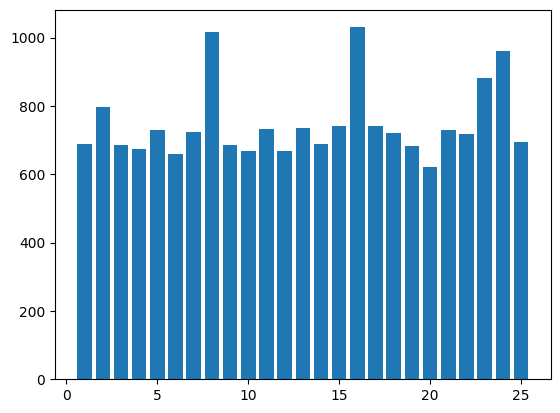

In [ ]:
counts = compute_correlation(clean_text)
plt.bar(range(1, 26), counts[:25])

длина ключа 8

In [ ]:
#PASSWORD_LEN = 8
groups = [""] * (PASSWORD_LEN + 1)

for i in range(PASSWORD_LEN):
  groups[i] += clean_text[i::PASSWORD_LEN]

groups.pop() #послдений элемент пустой

''

In [ ]:
# print(list(letter_frequency.keys())[:5])

https://eng4school.ru/the_alphabet/687-chastota-vstrechaemosti-bukv.html частотность букв в англйиском языке

In [ ]:
letter_frequency = {}

freq = """
Aa	8,17
Bb	1,49
Cc	2,78
Dd	4,25
Ee	12,70
Ff	2,23
Gg	2,02
Hh	6,09
Ii	6,97
Jj	0,15
Kk	0,77
Ll	4,03
Mm	2,41
Nn	6,75
Oo	7,51
Pp	1,93
Qq	0,10
Rr	5,99
Ss	6,33
Tt	9,06
Uu	2,76
Vv	0,98
Ww	2,36
Xx	0,15
Yy	1,97
Zz	0,07
"""

for i in freq.split('\n'):

  for j in i.strip().split(" "):
    if j:
      letter_frequency[j.split("\t")[0][1]] = float(j.split("\t")[1].replace(",", "."))
#sum(letter_frequency.values())
letter_frequency

{'a': 8.17,
 'b': 1.49,
 'c': 2.78,
 'd': 4.25,
 'e': 12.7,
 'f': 2.23,
 'g': 2.02,
 'h': 6.09,
 'i': 6.97,
 'j': 0.15,
 'k': 0.77,
 'l': 4.03,
 'm': 2.41,
 'n': 6.75,
 'o': 7.51,
 'p': 1.93,
 'q': 0.1,
 'r': 5.99,
 's': 6.33,
 't': 9.06,
 'u': 2.76,
 'v': 0.98,
 'w': 2.36,
 'x': 0.15,
 'y': 1.97,
 'z': 0.07}

<BarContainer object of 26 artists>

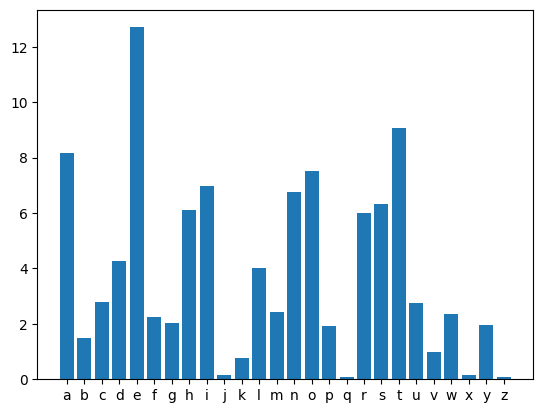

In [ ]:
plt.bar(letter_frequency.keys(), letter_frequency.values())

In [ ]:
def drow_freq(groups):
  gr_index = 0

  fig, ax = plt.subplots(2, 4, figsize =(20, 10))
  for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
      grp_freq = find_freq(groups[gr_index])
      #print(f"{sum(grp_freq.values()):.2f}")
      ax[i, j].bar(grp_freq.keys(), grp_freq.values())
      ax[i, j].set_title(f"Группа {gr_index}")
      gr_index+=1
  plt.tight_layout()
  plt.show()
#drow_freq(groups)

In [ ]:
PASSWORD_LEN = 8
groups = [""] * (PASSWORD_LEN + 1)

for i in range(PASSWORD_LEN):
  groups[i] += clean_text[i::PASSWORD_LEN]
groups.pop() #послдений элемент пустой


freqs = np.array(
    [find_freq(group).values() for group in groups]
) #частоты групп


In [ ]:
for i in groups:
  print(len(i))

2220
2220
2220
2220
2220
2220
2219
2219


In [ ]:

def join_groups(groups):
  joined_text = ""
  max_len = len(max(groups, key = lambda x: len(x)))
  for i in range(max_len):
    for group in groups:
      if i < len(group):
        joined_text += group[i]
  return joined_text
print(join_groups(groups))

#print("".join(["".join(x) for x in zip(*groups)])) #делеает тоже самое

wfcehcqvycefscprr,mn.xlcyxaj!:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnieftlct1.xysxqanvgjolhauxgtmehajaeidcazmgzfjehercprr!slwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajhahafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.xgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpderklvtpskvhhvlwlappoypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoypvwhptkezaszxsltwfmsfdrawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhpraraxspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxejexohwrcewx!msldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzitsazexpzp-wwxliywm,os

In [ ]:
def find_best_shift(freq, letter_frequency):
  errors = np.array([])
  freq = np.array([x for x in freq])
  expected_frequency = np.array([x for x in letter_frequency.values()])

  for i in range(26):
    shifted = np.roll(freq, -i)
    #err = np.sum((shifted - expected_frequency) ** 2)
    err = np.sum(((shifted - expected_frequency) ** 2) / expected_frequency)
    errors = np.append(errors, err)
  return np.argmin(errors)

best_shifts = []
for i in freqs:
   best_shifts.append(find_best_shift(i, letter_frequency))

best_shifts

[np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11)]

In [ ]:
find_freq(groups[0])

{'a': 5.18018018018018,
 'b': 1.1711711711711712,
 'c': 2.5225225225225225,
 'd': 3.6036036036036037,
 'e': 7.072072072072072,
 'f': 3.0180180180180183,
 'g': 2.6126126126126126,
 'h': 4.1891891891891895,
 'i': 3.6486486486486487,
 'j': 2.2972972972972974,
 'k': 2.9729729729729732,
 'l': 7.072072072072072,
 'm': 3.1081081081081083,
 'n': 2.2072072072072073,
 'o': 4.774774774774775,
 'p': 5.7207207207207205,
 'q': 1.3963963963963963,
 'r': 2.3873873873873874,
 's': 5.990990990990991,
 't': 4.2792792792792795,
 'u': 1.981981981981982,
 'v': 3.2432432432432434,
 'w': 4.1891891891891895,
 'x': 3.063063063063063,
 'y': 4.0990990990990985,
 'z': 4.81981981981982}

подобрав по самым высоким занчениям частотности:
1: 7
2: 4, 0, 19, 14
3: 0, 7, 14
4: 7
5: 0
6: 0
7: 7, 0

In [ ]:
def decrypt_vigenere(text, shifts):
    result = []
    letter_count = 0
    for ch in text.lower():
        if ch in ascii_lowercase:
            shift = shifts[letter_count % len(shifts)]
            result.append(caesar(ch, shift))
            letter_count += 1
        else:
            result.append(ch)
    return ''.join(result)

In [ ]:
best_shifts

[np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11)]

In [ ]:
#best_shifts
#clean_text = decrypt_vigenere(clean_text, best_shifts)
clean_text

'wfcehcqvycefscprr,mn.xlcyxaj!:eogejxmyidzfwgmymzfsylsyeneenfqymnsanhh.jpjnieftlct1.xysxqanvgjolhauxgtmehajaeidcazmgzfjehercprr!slwumhlswfgbxpwerifvvehehzwpwpeuledhftymulgbwp.ipgguwtdtahgmeyzlzagvhpypwgcprrmotxzhxtaupwzlpgpser.plloadisaic,ajhahafterxhxlydysgrjcpnyl-mvtpdlslhxzpswpdalpeiii.pewdodevhwezrwkwieeeenc,hrollwqhieyv.xgiytwdplwsexabwrcpapytzsouxzehajaci-lnz-llrlydcslzsxpskgclxdjoqgsuwnceshgdrezassgkiymaoi,hronojrwjxpotdiedmespeiulwzqbapddmcp.xcehotygzmxmicpnpggtftyapmguwzqssmljlpderklvtpskvhhvlwlappoypweggbporephamjpcejxnvpelgaw.iyehhwxaoeoypvwhptkezaszxsltwfmsfdrawazxlycahwwiyoskraawepmlijhxfce,wgalpceoydawzqmugssgfwapmguwhpraraxspswqwhweseoxmmjesapgstizftkjlointryyaa.mftexohwlwlnmyox,lnzazlresexydiwhpramfzicteo,sspsllb-dpx,ehacovywoghsgvszzoksgd,gprutjlxejexohwrcewx!msldwjmzitytdikfwepmosammdsonxwkeyjtdmfn,esebyklazflzfdva.yosmzhhezhwzwhjfdeplsaaldwaeclvesajxzljfdeerloiszuoi,zstxaziefshyfqwwzfjeagmfnxtyfkmdhrohrwthprrttwvgbrolnkpviycyt-smajfde.euysddmujmzitsazexpzp-wwxliywm,o

в cipher тексте есть подозрительный отрывок: ",xr.iwgjilu!:". Очень похоже на обращение Mr. получаем что ключ имеет формат: [x, 0, 4, x, x, x, x, x]

In [ ]:
best_shifts

[np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11),
 np.int64(4),
 np.int64(11),
 np.int64(11)]

In [ ]:
# for i in [15, 22]:
#   for j in [15]:
#     for k in [0]:
#       for l in [0, 15]:
#         for p in [0, 15, 22]:
#           best_shifts[:5] = [i, j, k, l, p]
#           print(decrypt_vigenere( clean_text, best_shifts)[:5])

Дальше можно заметить еще интересный момент в тексте: "xzehajaci-lnz-llrlydcslzsxpskg". Очень редкий формат, могут быть: -and-, -for-, -not-, -the-

In [ ]:
#decrypt_vigenere("lnz", [15, 0, 4]) # lnz -> and
#decrypt_vigenere("lnz", [20, 1, 18]) # lnz -> for
decrypt_vigenere("lnz", [13, 17, 20])

'yet'